In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np

from src.data_loader import get_prices
from src.backtest import run_backtest
from src.factor_analysis import compute_beta_alpha

In [3]:
tickers = ["AAPL", "TSLA", "SPY"]

prices = get_prices(tickers)

portfolio_returns, weights, regimes = run_backtest(
    prices,
    window=60,
    rebalance_freq=21,
    transaction_cost=0.001
)

[*********************100%***********************]  3 of 3 completed


In [4]:
market_returns = prices["SPY"].pct_change().dropna()

# align with portfolio
market_returns = market_returns.iloc[-len(portfolio_returns):]

In [5]:
portfolio_returns = portfolio_returns.reset_index(drop=True)
market_returns = market_returns.reset_index(drop=True)

In [6]:
alpha, beta, summary = compute_beta_alpha(
    portfolio_returns,
    market_returns
)

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: 0.0006512551634468641
Beta: 1.3394105636541376


## Factor Interpretation

- **Beta > 1** → strategy is more volatile than market  
- **Beta ≈ 1** → moves with market  
- **Beta < 1** → defensive  

- **Alpha > 0** → excess return beyond market exposure  
- **Alpha < 0** → underperforming strategy

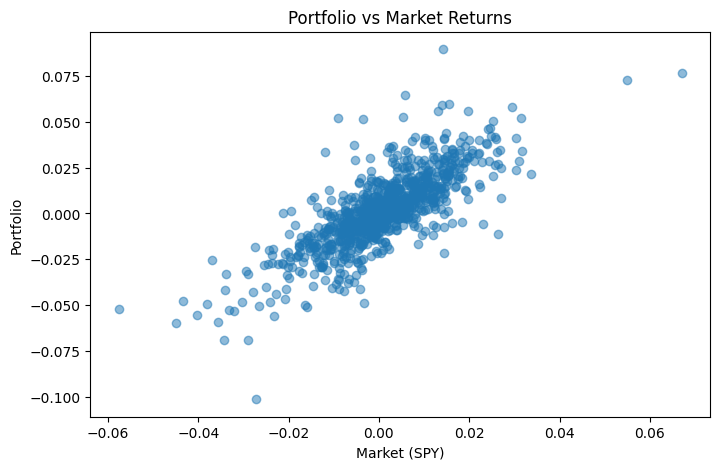

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(market_returns, portfolio_returns, alpha=0.5)

plt.title("Portfolio vs Market Returns")
plt.xlabel("Market (SPY)")
plt.ylabel("Portfolio")

plt.show()